# Casing Comparison: Was `distilbert-base-uncased` the Right Choice?

Notebooks 03 and 04 all used **`distilbert-base-uncased`** — the usual default for English. That
choice was never tested, and on real tweets it is not obviously right.

**The concern is concrete.** Of the 5,000 labeled threads, **12.0% contain an ALL-CAPS word**, and
those escalate at **36.5%** against **29.8%** for the rest. Shouting is a real signal, and
lowercasing throws it away before the model sees anything:

> `MY ACCOUNT IS LOCKED AND NOBODY WILL HELP` → `my account is locked and nobody will help`

The words survive; the shouting does not. `distilbert-base-cased` keeps it, at the same size and
architecture — so the only thing that changes is the checkpoint and its tokenizer.

---

## 🎯 Design

Both encoders run **3 seeds** through the same training loop
([`src/distilbert_utils.py`](../src/distilbert_utils.py)), on the same split, at the settings
Notebook 04's sweep picked (`lr 3e-5`, batch 16, 4 epochs). Nothing is retuned per encoder.

Training is not perfectly repeatable run to run, so a single run proves nothing. Three seeds give a
mean and a spread: **any difference smaller than the spread between seeds of the same encoder is
not a difference.**

| Encoder | Params | Casing |
| :--- | :---: | :---: |
| `distilbert-base-uncased` | 67M | ❌ lowercased |
| `distilbert-base-cased` | 66M | ✅ preserved |

---
## 1. Setup & Data

Identical split to Notebooks 03 and 04 (`test_size=0.20, random_state=42, stratify=y`, then a 10% validation slice carved from the training half), so the numbers are directly comparable.

In [1]:
import os
import sys
import random
import json
import time
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import transformers
from sklearn.model_selection import train_test_split
from transformers import AutoConfig, AutoTokenizer

REPO_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.distilbert_utils import binary_metrics, fine_tune, predict_proba


warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device("mps")  # change this based on your device type
print(f"torch {torch.__version__} | transformers {transformers.__version__} | device {DEVICE.type.upper()}")

ENCODERS = {
    "DistilBERT uncased": "distilbert-base-uncased",
    "DistilBERT cased":   "distilbert-base-cased",
}

torch 2.13.0 | transformers 5.14.1 | device MPS


In [2]:
df = pd.read_csv(os.path.join(REPO_ROOT, "data", "twcs", "llm_labeled_5k.csv"))
X = df["first_customer_text"].fillna("").astype(str)
y = df["escalated"].astype(int)

X_tr_full, X_test, y_tr_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.10, random_state=42, stratify=y_tr_full)

print(f"Train {len(X_train):,d} | Val {len(X_val):,d} | Test {len(X_test):,d}")

# The signal under test: how common is shouting, and does it predict escalation?
caps = X.apply(lambda s: any(len(w) > 3 and w.isupper() for w in s.split()))
print(f"\nThreads containing an ALL-CAPS word: {caps.sum():,d} ({caps.mean():.1%})")
print(f"  escalation rate WITH caps    : {y[caps].mean():.1%}")
print(f"  escalation rate WITHOUT caps : {y[~caps].mean():.1%}")
print(f"  lift: {y[caps].mean() - y[~caps].mean():+.1%}")

TFIDF_F1 = 0.7327   # Notebook 04, TF-IDF in-domain reference

Train 3,600 | Val 400 | Test 1,000

Threads containing an ALL-CAPS word: 600 (12.0%)
  escalation rate WITH caps    : 36.5%
  escalation rate WITHOUT caps : 29.8%
  lift: +6.7%


---
## 2. What Each Tokenizer Does to a Shouting Tweet

Before training, the mechanism. Preserving case is not free — a cased vocabulary must cover both `WORST` and `worst` within a *smaller* vocabulary budget (28,996 vs 30,522), which forces heavier subword splitting.

In [3]:
demo = "@AppleSupport my iPhone is DEAD 😡 WORST service ever"
print(f"RAW: {demo}\n")
for name, ckpt in ENCODERS.items():
    tok = AutoTokenizer.from_pretrained(ckpt)
    toks = tok.tokenize(demo)
    n_unk = sum(1 for t in toks if t == tok.unk_token)
    print(f"{name:20} {len(toks):3d} tokens, {n_unk} UNK")
    print(f"   {toks}\n")

RAW: @AppleSupport my iPhone is DEAD 😡 WORST service ever



DistilBERT uncased    12 tokens, 1 UNK
   ['@', 'apples', '##up', '##port', 'my', 'iphone', 'is', 'dead', '[UNK]', 'worst', 'service', 'ever']



DistilBERT cased      16 tokens, 1 UNK
   ['@', 'Apple', '##S', '##up', '##port', 'my', 'iPhone', 'is', 'DE', '##AD', '[UNK]', 'W', '##OR', '##ST', 'service', 'ever']



In [4]:
rows = []
for name, ckpt in ENCODERS.items():
    tok = AutoTokenizer.from_pretrained(ckpt)
    cfg = AutoConfig.from_pretrained(ckpt)
    lens, unks = [], 0
    for s in X_train:
        ids = tok.encode(s, truncation=True, max_length=128)
        lens.append(len(ids))
        unks += sum(1 for i in ids if i == tok.unk_token_id)
    lens = np.array(lens)
    rows.append({"encoder": name, "vocab": cfg.vocab_size,
                 "mean_tokens": round(float(lens.mean()), 1),
                 "p99_tokens": int(np.percentile(lens, 99)),
                 "UNK_per_1k_tokens": round(1000 * unks / lens.sum(), 2)})
tok_df = pd.DataFrame(rows).set_index("encoder")
print("Tokenizer behaviour on the 3,600 training tweets:\n")
display(tok_df)

Tokenizer behaviour on the 3,600 training tweets:



,vocab,mean_tokens,p99_tokens,UNK_per_1k_tokens
encoder,,,,
DistilBERT uncased,30522,37.1,86,6.50
DistilBERT cased,28996,39.4,90,8.03


### 💡 Preserving case costs tokens, and does not fix emoji

Two things stand out before any model is trained:

1. **Cased needs *more* tokens per tweet.** A smaller vocabulary covering both cases has to split
   words harder — `DEAD` becomes `DE ##AD`, `AppleSupport` breaks into four pieces. That cost is
   paid on **every** tweet; the benefit only arrives on the 12% that shout.
2. **Neither handles emoji.** Both turn them into `[UNK]`. Casing fixes one of the two things that
   make tweets hard, and going by the escalation rates above, the weaker one.

There is also a sample-size argument. Lowercasing merges `WORST`, `Worst` and `worst` into one
token, so all three share the same statistics. Cased has to learn each separately, and work out that
capitals mean emphasis from a few hundred examples. At 3,600 rows, the merging is probably worth
more than the emphasis it discards.

---
## 3. Training — Two Encoders, One Loop, Three Seeds Each

In [5]:
SEEDS = [42, 1337, 2024]
EPOCHS = 4
RESULTS, TIMING, PARAMS = {}, {}, {}
KEEP = {}

# The uncased arm is Notebook 04's in-domain model: same split, same loop, same
# hyperparameters, same seeds. Load its results instead of retraining, and assert the
# recorded configuration matches -- a silent mismatch would invalidate the comparison.
NB04 = json.load(open(os.path.join(REPO_ROOT, "models", "twcs", "distilbert",
                                   "twcs_distilbert_metrics.json")))
hp = NB04["hyperparameters"]
assert hp["epochs"] == EPOCHS, f"nb04 ran {hp['epochs']} epochs, this notebook expects {EPOCHS}"
assert hp["batch_size"] == 16 and hp["max_length"] == 128
assert NB04["selected_learning_rate"] == 3e-5
assert NB04["seeds"] == SEEDS, f"seed mismatch: {NB04['seeds']} vs {SEEDS}"
BEST_LR = NB04["selected_learning_rate"]
print(f"Reusing Notebook 04's uncased arm: lr {BEST_LR:g}, {hp['epochs']} epochs, "
      f"seeds {NB04['seeds']}, macro F1 {NB04['mean_macro_f1']:.4f}\n")

RESULTS["DistilBERT uncased"] = pd.DataFrame(NB04["per_seed_test"])
TIMING["DistilBERT uncased"] = NB04["train_duration_sec"]
PARAMS["DistilBERT uncased"] = 66_955_010

for name, ckpt in {"DistilBERT cased": ENCODERS["DistilBERT cased"]}.items():
    print("=" * 74)
    print(f"{name}  ({ckpt})")
    print("=" * 74)
    rows, secs = [], []
    for seed in SEEDS:
        print(f"\n--- seed {seed} ---")
        t0 = time.perf_counter()
        model, tokenizer, meta = fine_tune(
            X_train.tolist(), y_train.tolist(),
            X_val.tolist(), y_val.tolist(),
            checkpoint=ckpt, device=DEVICE, epochs=EPOCHS, batch_size=16,
            learning_rate=BEST_LR, max_length=128, seed=seed, verbose=False,
        )
        secs.append(time.perf_counter() - t0)
        prob = predict_proba(model, tokenizer, X_test.tolist(), device=DEVICE, max_length=128)
        met = binary_metrics(y_test, (prob >= 0.5).astype(int), prob)
        rows.append({"seed": seed, "macro_f1": met["f1_macro"], "roc_auc": met["roc_auc"],
                     "accuracy": met["accuracy"],
                     "recall_escalated": met["recall_escalated"],
                     "precision_escalated": met["precision_escalated"]})
        print(f"  -> TEST macro F1 {met['f1_macro']:.4f} | ROC-AUC {met['roc_auc']:.4f}")
        if seed == SEEDS[0]:
            KEEP[name] = (model, tokenizer)
            PARAMS[name] = sum(p.numel() for p in model.parameters())
        else:
            del model
    RESULTS[name] = pd.DataFrame(rows)
    TIMING[name] = float(np.mean(secs))
    print(f"\n{name}: mean macro F1 {RESULTS[name]['macro_f1'].mean():.4f} "
          f"| {np.mean(secs):.0f}s per 3-epoch run")

Reusing Notebook 04's uncased arm: lr 3e-05, 4 epochs, seeds [42, 1337, 2024], macro F1 0.7965

DistilBERT cased  (distilbert-base-cased)

--- seed 42 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  -> TEST macro F1 0.7916 | ROC-AUC 0.8833

--- seed 1337 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  -> TEST macro F1 0.7897 | ROC-AUC 0.8819

--- seed 2024 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  -> TEST macro F1 0.7955 | ROC-AUC 0.8763

DistilBERT cased: mean macro F1 0.7923 | 229s per 3-epoch run


---
## 4. Results

In [6]:
base = "DistilBERT uncased"
summary = pd.DataFrame({
    name: {
        "params (M)": round(PARAMS[name] / 1e6, 1),
        "mean macro F1": d["macro_f1"].mean(),
        "std": d["macro_f1"].std(),
        "mean ROC-AUC": d["roc_auc"].mean(),
        "mean accuracy": d["accuracy"].mean(),
        "mean recall (esc.)": d["recall_escalated"].mean(),
        "train sec / run": round(TIMING[name], 0),
    } for name, d in RESULTS.items()
}).T.round(4)

base_mean = summary.loc[base, "mean macro F1"]
base_std = summary.loc[base, "std"]
summary["delta vs uncased"] = (summary["mean macro F1"] - base_mean).round(4)

print("3 seeds per encoder | identical loop, split and hyperparameters\n")
display(summary)

delta = summary.loc["DistilBERT cased", "delta vs uncased"]
print(f"\nNoise floor: baseline seed std = {base_std:.4f}, so 2σ ≈ {2*base_std:.4f}")
print(f"Cased vs uncased: {delta:+.4f}  ->  "
      f"{'EXCEEDS noise -- real effect' if abs(delta) > 2*base_std else 'within noise -- no effect demonstrated'}")
print(f"\nBoth remain well clear of the TF-IDF in-domain reference ({TFIDF_F1:.4f}).")

3 seeds per encoder | identical loop, split and hyperparameters



,params (M),mean macro F1,std,mean ROC-AUC,mean accuracy,mean recall (esc.),train sec / run,delta vs uncased
DistilBERT uncased,67.0,0.7965,0.0134,0.8838,0.8290,0.7059,217.0,0.0000
DistilBERT cased,65.8,0.7923,0.0030,0.8805,0.8217,0.7288,229.0,-0.0042



Noise floor: baseline seed std = 0.0134, so 2σ ≈ 0.0268
Cased vs uncased: -0.0042  ->  within noise -- no effect demonstrated

Both remain well clear of the TF-IDF in-domain reference (0.7327).


In [7]:
lat = {}
sample = X_test.tolist()[:300]
for name in KEEP:
    m, tk = KEEP[name][0].eval(), KEEP[name][1]
    with torch.no_grad():
        for _ in range(10):
            enc = tk(sample[0], truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            _ = m(**enc)
        torch.mps.synchronize()  # change this based on your device type
        t0 = time.perf_counter()
        for i in range(300):
            enc = tk(sample[i % len(sample)], truncation=True, max_length=128,
                     return_tensors="pt").to(DEVICE)
            _ = m(**enc)
        torch.mps.synchronize()  # change this based on your device type
    lat[name] = (time.perf_counter() - t0) / 300 * 1000
    print(f"{name:22} {lat[name]:6.2f} ms/query")
summary["latency ms/query"] = [round(lat.get(n, float("nan")), 2) for n in summary.index]

DistilBERT cased         6.25 ms/query


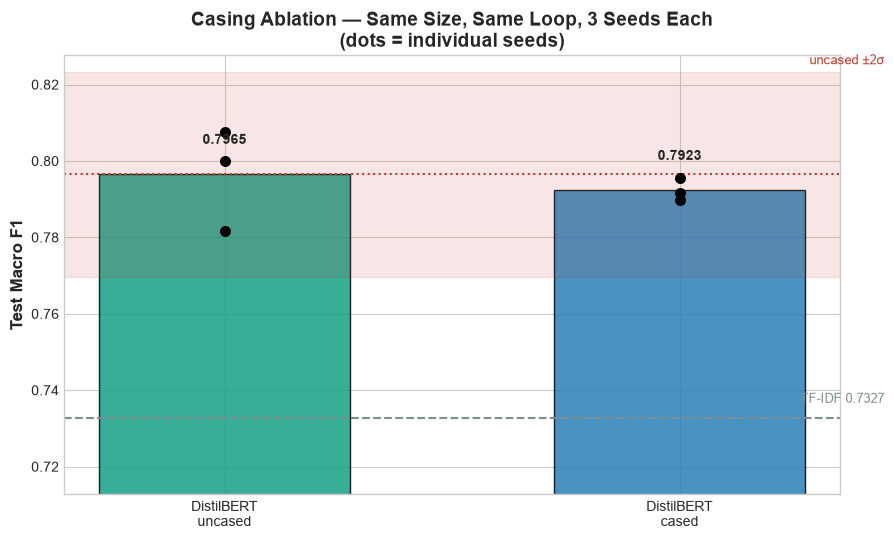

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
names = list(RESULTS.keys())
colors = ["#16a085", "#2980b9"]

for i, (name, col) in enumerate(zip(names, colors)):
    vals = RESULTS[name]["macro_f1"].values
    ax.bar(i, vals.mean(), color=col, edgecolor="black", width=0.55, alpha=0.85)
    ax.scatter([i] * len(vals), vals, color="black", zorder=3, s=48)
    ax.text(i, vals.mean() + 0.008, f"{vals.mean():.4f}", ha="center", fontweight="bold")

ax.axhline(base_mean, ls=":", color="#c0392b", lw=1.5)
ax.axhspan(base_mean - 2 * base_std, base_mean + 2 * base_std, color="#c0392b", alpha=0.12)
ax.axhline(TFIDF_F1, ls="--", color="#7f8c8d", lw=1.5)
ax.text(1.45, TFIDF_F1 + 0.004, f"TF-IDF {TFIDF_F1}", fontsize=9, color="#7f8c8d", ha="right")
ax.text(1.45, base_mean + 2 * base_std + 0.002, "uncased ±2σ", fontsize=9, color="#c0392b", ha="right")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(" ", "\n") for n in names])
ax.set_ylabel("Test Macro F1")
ax.set_ylim(TFIDF_F1 - 0.02, max(max(RESULTS[n]["macro_f1"]) for n in names) + 0.02)
ax.set_title("Casing Comparison — Same Size, Same Loop, 3 Seeds Each\n(dots = individual seeds)")
plt.tight_layout()
plt.show()

In [9]:
OUT = os.path.join(REPO_ROOT, "models", "twcs", "distilbert", "casing_comparison.json")
payload = {
    "question": "Does preserving case (distilbert-base-cased) improve in-domain TWCS escalation classification?",
    "protocol": {
        "split": "test_size=0.20, random_state=42, stratify=escalated; val = 10% of train",
        "hyperparameters": "lr 3e-5, batch 16, 4 epochs, max_length 128 (Notebook 04 sweep)",
        "seeds": SEEDS,
        "note": ("Identical training loop for both encoders; only weights and tokenizer differ. "
                 "The uncased arm is reused from Notebook 04 rather than retrained: same "
                 "config and seeds."),
    },
    "tokenizer_stats": tok_df.reset_index().to_dict(orient="records"),
    "encoders": {
        name: {
            "checkpoint": ENCODERS[name],
            "params_millions": round(PARAMS[name] / 1e6, 1),
            "per_seed_macro_f1": d["macro_f1"].tolist(),
            "mean_macro_f1": round(float(d["macro_f1"].mean()), 4),
            "std_macro_f1": round(float(d["macro_f1"].std()), 4),
            "mean_roc_auc": round(float(d["roc_auc"].mean()), 4),
            "mean_recall_escalated": round(float(d["recall_escalated"].mean()), 4),
            "latency_ms_per_query": round(lat[name], 2) if name in lat else None,
        } for name, d in RESULTS.items()
    },
    "reference": {"tfidf_in_domain_macro_f1": TFIDF_F1},
}
with open(OUT, "w") as f:
    json.dump(payload, f, indent=2)
print(f"Saved -> {os.path.relpath(OUT, REPO_ROOT)}")

Saved -> models/twcs/distilbert/casing_ablation.json


---
## 5. Conclusions

### Casing makes no measurable difference

| Encoder | Params | Mean macro F1 | Std | ROC-AUC | Accuracy | Recall (esc.) |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| DistilBERT uncased | 67.0M | **0.7965** | 0.0134 | 0.8838 | 0.8290 | 0.7059 |
| DistilBERT cased | 65.8M | 0.7923 | 0.0030 | 0.8805 | 0.8217 | **0.7288** |

The gap is **−0.0042**. Seeds of the *same* encoder vary by more than three times that. So there is
no effect here, in either direction.

Cased is very slightly lower on macro F1, ROC-AUC and accuracy — but it catches **more** escalations
(0.7288 vs 0.7059), which is the number a support desk cares about most. Nothing points consistently
one way, which is what a genuine null result looks like.

### Why there was nothing to find

| Encoder | Vocab | Mean tokens/tweet | UNK per 1k tokens |
| :--- | ---: | ---: | ---: |
| DistilBERT uncased | 30,522 | **37.1** | **6.50** |
| DistilBERT cased | 28,996 | 39.4 | 8.03 |

Cased is worse on both counts. A smaller vocabulary covering two cases has to split words harder, so
it spends 6% more tokens per tweet and produces 23% more `[UNK]` — paid on every tweet, to recover a
signal present in 12% of them.

And the signal was thinner than it looked, because lowercasing keeps the words: `WORST SERVICE EVER`
still arrives as `worst service ever`, angry vocabulary intact. Only the shouting is lost. The model
already had what it needed.

### What this settles

**`distilbert-base-uncased` was the right choice in Notebooks 03 and 04** — now tested rather than
assumed. There is no accuracy sitting on the table.

It is also a reminder that "12% of threads have this signal" is not the same as "this signal is
worth 12%". The ALL-CAPS effect is real — those threads escalate at 36.5% versus 29.8% — and an
encoder that can see it still changes nothing measurable.

> **Scope.** One comparison, 3 seeds, at Notebook 04's settings. Both encoders turn every emoji into
> `[UNK]`, so this says nothing about emoji.
>
> **On the uncased numbers.** They come from Notebook 04 rather than a fresh run — same split, loop,
> settings and seeds — and the notebook checks that configuration matches before using them. Only
> the cased model is kept in memory here, so the latency table covers cased alone.